In [12]:
# DS-7331 Lab Two -

### By Ahmad Salama, Titus Karuri, Eman Meraj, Sue Camara

In [13]:
# ---------------------------------------------------------
# Python Library Setup: Check and Install Required Dependencies
# ---------------------------------------------------------
import sys
import subprocess
import importlib.util as imp_util

# List of required libraries\packages for this notebook
required_packages = [
    "pandas",
    "missingno",
    "seaborn",
    "matplotlib",
    "math",
    "scikit-learn",
    "numpy"
]

for package in required_packages:
    # iterate over the required packages and if any is not installed, trigger a pip command
    # to install.
    if imp_util.find_spec(package) is None:
        print(f"Package '{package}' is not installed. Installing now...")
        # run the pip command
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", package],
            stdout=subprocess.DEVNULL
        )
        print(f"Package '{package}' installed successfully.\n")
    else:
        print(f"Package '{package}' is already installed.\n")

# ---------------------------------------------------------
# Import required libraries\packages
# ---------------------------------------------------------
import numpy as np
import pandas as pd
import os as os
import seaborn as sns
import missingno as msno
import matplotlib.pyplot as plt
from sklearn import metrics as mt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import ShuffleSplit
from sklearn.svm import SVC
import os

Package 'pandas' is already installed.

Package 'missingno' is already installed.

Package 'seaborn' is already installed.

Package 'matplotlib' is already installed.

Package 'math' is already installed.

Package 'scikit-learn' is not installed. Installing now...
Package 'scikit-learn' installed successfully.

Package 'numpy' is already installed.



In [14]:

DATASET_NAME = "default_of_credit_card_clients.csv"
data_path = os.path.join(os.getcwd(), "data", DATASET_NAME)

# load the dataset
df = pd.read_csv(data_path, header=1)
df.info

<bound method DataFrame.info of           ID  LIMIT_BAL  SEX  EDUCATION  MARRIAGE  AGE  PAY_0  PAY_2  PAY_3  \
0          1      20000    2          2         1   24      2      2     -1   
1          2     120000    2          2         2   26     -1      2      0   
2          3      90000    2          2         2   34      0      0      0   
3          4      50000    2          2         1   37      0      0      0   
4          5      50000    1          2         1   57     -1      0     -1   
...      ...        ...  ...        ...       ...  ...    ...    ...    ...   
29995  29996     220000    1          3         1   39      0      0      0   
29996  29997     150000    1          3         2   43     -1     -1     -1   
29997  29998      30000    1          2         2   37      4      3      2   
29998  29999      80000    1          3         1   41      1     -1      0   
29999  30000      50000    1          2         1   46      0      0      0   

       PAY_4  ...  

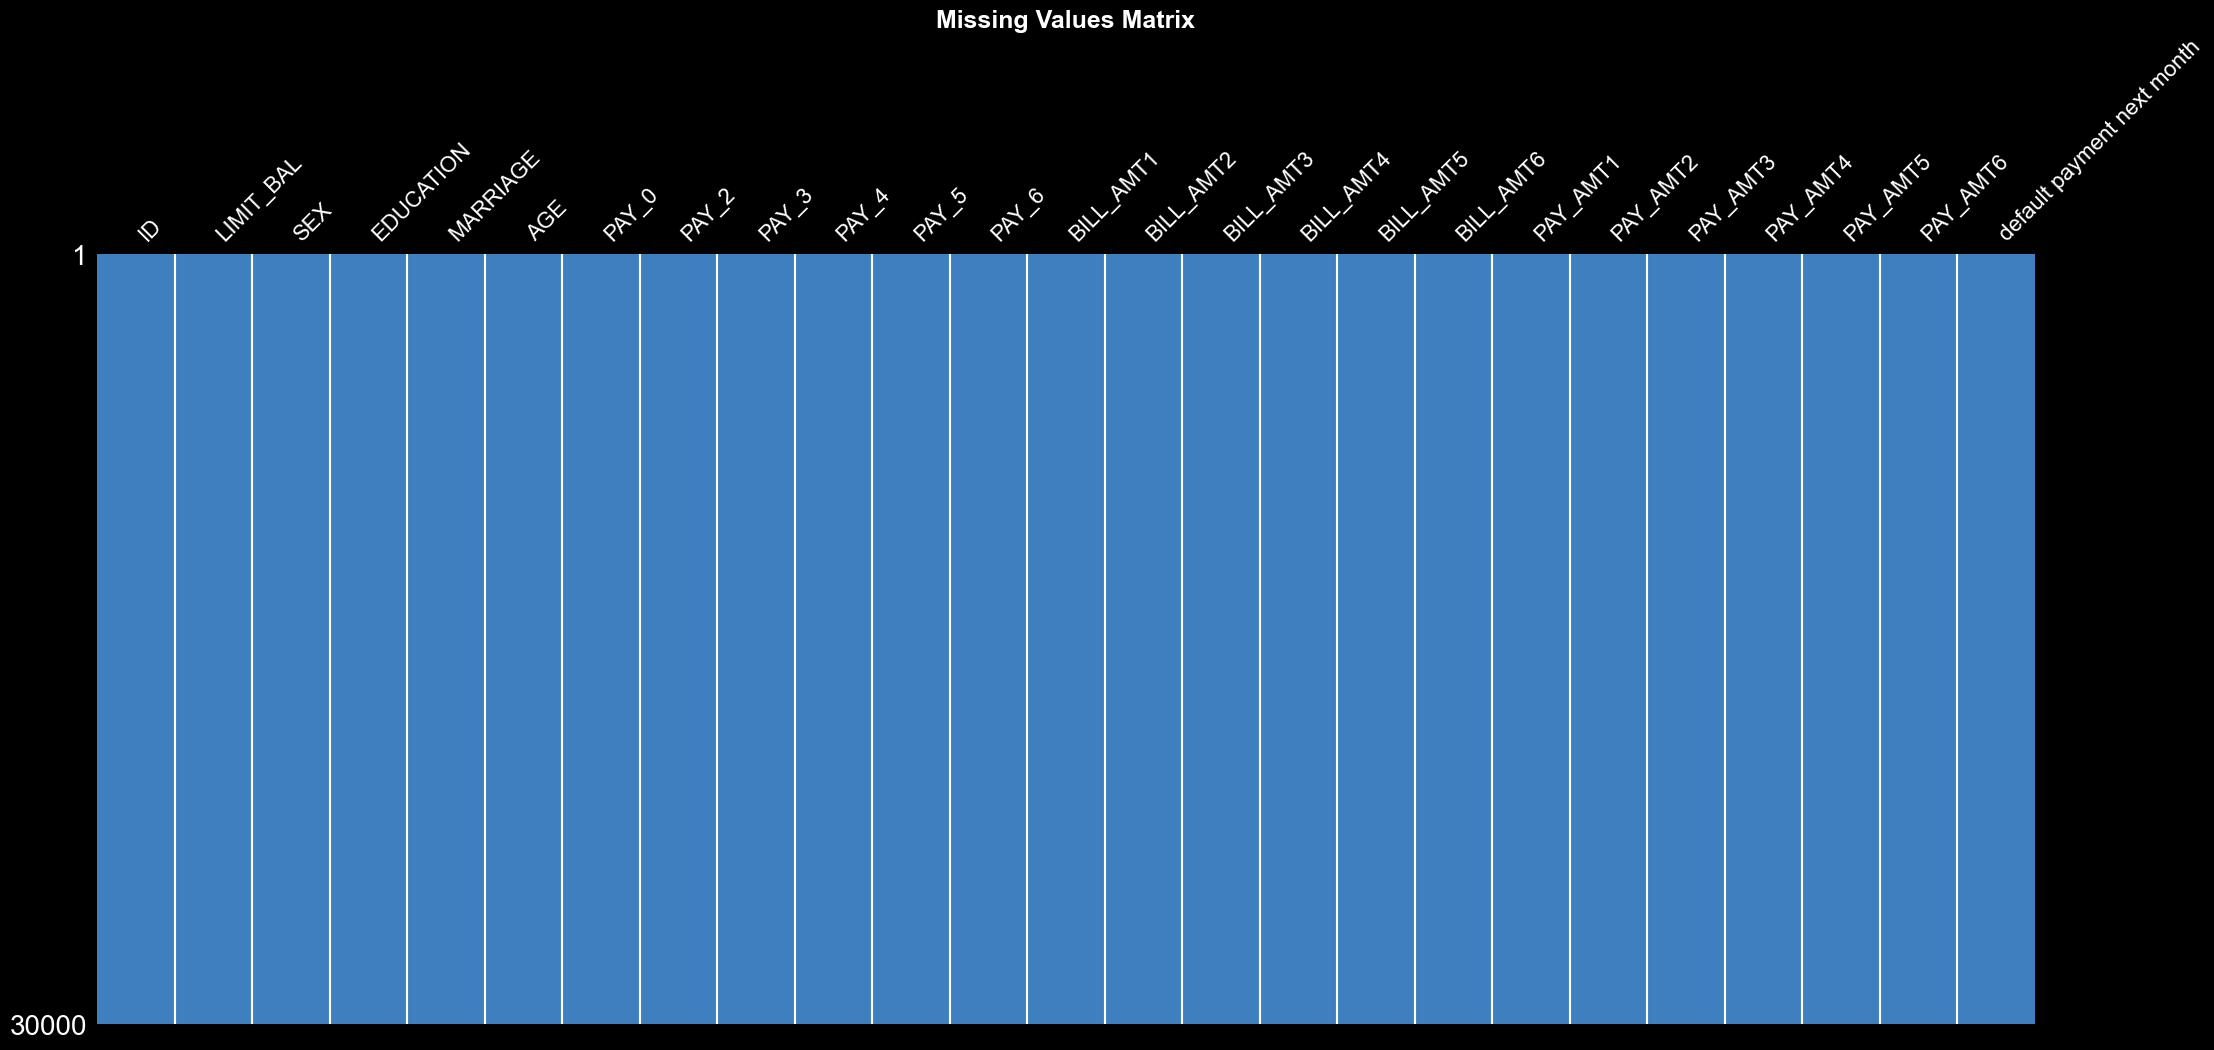

In [15]:
# Visualize dataset completeness using a missingno matrix plot
msno.matrix(
    df,
    color=(0.25, 0.5, 0.75),
    sparkline=False
)
plt.title("Missing Values Matrix", fontsize=18, fontweight="bold")
plt.show()

In [16]:
# Drop the ID column - it's just a row identifier, not useful for prediction
df.drop('ID', axis=1, inplace=True)
print("Dropped 'ID' column (row identifier, not predictive).\n")

# Rename target column for convenience
df.rename(columns={'default payment next month': 'DEFAULT'}, inplace=True)

# Rename PAY_0 to PAY_1 for consistency (it represents September payment status)
df.rename(columns={'PAY_0': 'PAY_1'}, inplace=True)

Dropped 'ID' column (row identifier, not predictive).



In [17]:
# EDUCATION: 0, 5, 6 are undocumented categories
# 1=graduate school, 2=university, 3=high school, 4=others
# Merge 0, 5, 6 into 4 (others)
print("EDUCATION before cleaning:")
print(df['EDUCATION'].value_counts().sort_index())
df['EDUCATION'] = df['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
print("\nEDUCATION after cleaning (0,5,6 -> 4=Others):")
print(df['EDUCATION'].value_counts().sort_index())

# MARRIAGE: 0 is undocumented
# 1=married, 2=single, 3=others
# Merge 0 into 3 (others)
print("\nMARRIAGE before cleaning:")
print(df['MARRIAGE'].value_counts().sort_index())
df['MARRIAGE'] = df['MARRIAGE'].replace({0: 3})
print("\nMARRIAGE after cleaning (0 -> 3=Others):")
print(df['MARRIAGE'].value_counts().sort_index())

EDUCATION before cleaning:
EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

EDUCATION after cleaning (0,5,6 -> 4=Others):
EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

MARRIAGE before cleaning:
MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

MARRIAGE after cleaning (0 -> 3=Others):
MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64


In [18]:
# Categorize all variables by their proper type
variable_types = {
    'LIMIT_BAL': 'continuous (float)',
    'SEX': 'binary categorical (int)',
    'EDUCATION': 'ordinal categorical (int)',
    'MARRIAGE': 'nominal categorical (int)',
    'AGE': 'continuous (int)',
    'PAY_1': 'ordinal (int) - repayment status Sept',
    'PAY_2': 'ordinal (int) - repayment status Aug',
    'PAY_3': 'ordinal (int) - repayment status Jul',
    'PAY_4': 'ordinal (int) - repayment status Jun',
    'PAY_5': 'ordinal (int) - repayment status May',
    'PAY_6': 'ordinal (int) - repayment status Apr',
    'BILL_AMT1': 'continuous (float) - bill statement Sept',
    'BILL_AMT2': 'continuous (float) - bill statement Aug',
    'BILL_AMT3': 'continuous (float) - bill statement Jul',
    'BILL_AMT4': 'continuous (float) - bill statement Jun',
    'BILL_AMT5': 'continuous (float) - bill statement May',
    'BILL_AMT6': 'continuous (float) - bill statement Apr',
    'PAY_AMT1': 'continuous (float) - payment Sept',
    'PAY_AMT2': 'continuous (float) - payment Aug',
    'PAY_AMT3': 'continuous (float) - payment Jul',
    'PAY_AMT4': 'continuous (float) - payment Jun',
    'PAY_AMT5': 'continuous (float) - payment May',
    'PAY_AMT6': 'continuous (float) - payment Apr',
    'DEFAULT': 'binary target (int)'
}

print("\n\n=== VARIABLE TYPE DEFINITIONS ===")
for var, vtype in variable_types.items():
    print(f"  {var:15s} -> {vtype}")




=== VARIABLE TYPE DEFINITIONS ===
  LIMIT_BAL       -> continuous (float)
  SEX             -> binary categorical (int)
  EDUCATION       -> ordinal categorical (int)
  MARRIAGE        -> nominal categorical (int)
  AGE             -> continuous (int)
  PAY_1           -> ordinal (int) - repayment status Sept
  PAY_2           -> ordinal (int) - repayment status Aug
  PAY_3           -> ordinal (int) - repayment status Jul
  PAY_4           -> ordinal (int) - repayment status Jun
  PAY_5           -> ordinal (int) - repayment status May
  PAY_6           -> ordinal (int) - repayment status Apr
  BILL_AMT1       -> continuous (float) - bill statement Sept
  BILL_AMT2       -> continuous (float) - bill statement Aug
  BILL_AMT3       -> continuous (float) - bill statement Jul
  BILL_AMT4       -> continuous (float) - bill statement Jun
  BILL_AMT5       -> continuous (float) - bill statement May
  BILL_AMT6       -> continuous (float) - bill statement Apr
  PAY_AMT1        -> continuou

In [19]:
# ============================================================
# 5. FEATURE ENGINEERING
# ============================================================
print("\n\n=== FEATURE ENGINEERING ===\n")

# 5a. Credit Utilization Ratio (average across 6 months)
# Ratio of bill amount to credit limit - measures how much of the credit line is used
bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
for i, col in enumerate(bill_cols, 1):
    df[f'UTIL_RATIO_{i}'] = df[col] / df['LIMIT_BAL']

df['AVG_UTIL_RATIO'] = df[[f'UTIL_RATIO_{i}' for i in range(1,7)]].mean(axis=1)
print("Created: UTIL_RATIO_1 through UTIL_RATIO_6 and AVG_UTIL_RATIO (credit utilization ratios)")

# 5b. Payment-to-Bill Ratio (how much of the bill was paid)
pay_amt_cols = ['PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']
for i in range(1, 7):
    bill_col = f'BILL_AMT{i}'
    pay_col = f'PAY_AMT{i}'
    # Avoid division by zero; if bill is 0 or negative, set ratio to 1 (fully paid)
    df[f'PAY_RATIO_{i}'] = np.where(
        df[bill_col] > 0,
        df[pay_col] / df[bill_col],
        1.0  # If no bill, consider it paid
    )
    # Cap at reasonable values to avoid extreme outliers
    df[f'PAY_RATIO_{i}'] = df[f'PAY_RATIO_{i}'].clip(0, 5)

df['AVG_PAY_RATIO'] = df[[f'PAY_RATIO_{i}' for i in range(1,7)]].mean(axis=1)
print("Created: PAY_RATIO_1 through PAY_RATIO_6 and AVG_PAY_RATIO (payment-to-bill ratios)")

# 5c. Average and Max Payment Delay
pay_status_cols = ['PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
df['AVG_PAY_STATUS'] = df[pay_status_cols].mean(axis=1)
df['MAX_PAY_STATUS'] = df[pay_status_cols].max(axis=1)
print("Created: AVG_PAY_STATUS (average repayment status), MAX_PAY_STATUS (worst repayment status)")

# 5d. Number of times payment was delayed (PAY_X >= 1)
df['NUM_DELAYS'] = (df[pay_status_cols] >= 1).sum(axis=1)
print("Created: NUM_DELAYS (count of months with payment delay >= 1)")

# 5e. Number of times payment was severely delayed (PAY_X >= 3)
df['NUM_SEVERE_DELAYS'] = (df[pay_status_cols] >= 3).sum(axis=1)
print("Created: NUM_SEVERE_DELAYS (count of months with payment delay >= 3)")

# 5f. Total bill amount and total payment amount over 6 months
df['TOTAL_BILL'] = df[bill_cols].sum(axis=1)
df['TOTAL_PAY'] = df[pay_amt_cols].sum(axis=1)
print("Created: TOTAL_BILL (sum of 6 months bills), TOTAL_PAY (sum of 6 months payments)")

# 5g. Balance trend (is the balance increasing or decreasing?)
# Positive means balance is growing (bad sign)
df['BILL_TREND'] = df['BILL_AMT1'] - df['BILL_AMT6']
print("Created: BILL_TREND (Sept bill - Apr bill; positive = growing balance)")

# 5h. Age group (binned)
df['AGE_GROUP'] = pd.cut(df['AGE'], bins=[20, 30, 40, 50, 60, 80], labels=[1, 2, 3, 4, 5]).astype(int)
print("Created: AGE_GROUP (1=21-30, 2=31-40, 3=41-50, 4=51-60, 5=61+)")




=== FEATURE ENGINEERING ===

Created: UTIL_RATIO_1 through UTIL_RATIO_6 and AVG_UTIL_RATIO (credit utilization ratios)
Created: PAY_RATIO_1 through PAY_RATIO_6 and AVG_PAY_RATIO (payment-to-bill ratios)
Created: AVG_PAY_STATUS (average repayment status), MAX_PAY_STATUS (worst repayment status)
Created: NUM_DELAYS (count of months with payment delay >= 1)
Created: NUM_SEVERE_DELAYS (count of months with payment delay >= 3)
Created: TOTAL_BILL (sum of 6 months bills), TOTAL_PAY (sum of 6 months payments)
Created: BILL_TREND (Sept bill - Apr bill; positive = growing balance)
Created: AGE_GROUP (1=21-30, 2=31-40, 3=41-50, 4=51-60, 5=61+)


In [20]:
# ============================================================
# 6. CREATE MULTI-CLASS TARGET FOR TASK 2
# ============================================================
print("\n\n=== MULTI-CLASS TARGET CREATION (Task 2) ===\n")

# Based on the most recent payment status (PAY_1, which is September)
# But to be more robust, use the worst payment status across all 6 months
def classify_payment_behavior(row):
    """
    Classify payment behavior based on worst repayment status across 6 months.
    Class 0: Good payers (all PAY_X <= 0) - no delinquency
    Class 1: Minor delinquency (worst PAY_X in {1, 2}) - 1-2 months delay
    Class 2: Major delinquency (worst PAY_X >= 3) - 3+ months delay
    """
    max_status = row[pay_status_cols].max()
    if max_status <= 0:
        return 0  # Good payer
    elif max_status <= 2:
        return 1  # Minor delinquency
    else:
        return 2  # Major delinquency

df['PAY_BEHAVIOR'] = df.apply(classify_payment_behavior, axis=1)

print("PAY_BEHAVIOR distribution:")
print(df['PAY_BEHAVIOR'].value_counts().sort_index())
print(f"\nClass 0 (Good payers): {(df['PAY_BEHAVIOR']==0).sum()} ({(df['PAY_BEHAVIOR']==0).mean()*100:.1f}%)")
print(f"Class 1 (Minor delinquency): {(df['PAY_BEHAVIOR']==1).sum()} ({(df['PAY_BEHAVIOR']==1).mean()*100:.1f}%)")
print(f"Class 2 (Major delinquency): {(df['PAY_BEHAVIOR']==2).sum()} ({(df['PAY_BEHAVIOR']==2).mean()*100:.1f}%)")



=== MULTI-CLASS TARGET CREATION (Task 2) ===

PAY_BEHAVIOR distribution:
PAY_BEHAVIOR
0    19931
1     8876
2     1193
Name: count, dtype: int64

Class 0 (Good payers): 19931 (66.4%)
Class 1 (Minor delinquency): 8876 (29.6%)
Class 2 (Major delinquency): 1193 (4.0%)


In [21]:
# ============================================================
# 7. ONE-HOT ENCODING FOR NOMINAL CATEGORICAL VARIABLES
# ============================================================
print("\n\n=== ONE-HOT ENCODING ===\n")

# SEX: Binary, can be kept as is (1=male, 2=female) or converted to 0/1
df['IS_FEMALE'] = (df['SEX'] == 2).astype(int)
print("Created IS_FEMALE (binary: 1=female, 0=male) from SEX")

# EDUCATION: Ordinal but we'll one-hot encode since the categories are not strictly ordered
# (graduate school is "higher" than university, but "others" doesn't fit the ordering)
edu_dummies = pd.get_dummies(df['EDUCATION'], prefix='EDU', dtype=int)
edu_dummies.columns = ['EDU_GRAD_SCHOOL', 'EDU_UNIVERSITY', 'EDU_HIGH_SCHOOL', 'EDU_OTHER']
# Drop one to avoid multicollinearity (drop EDU_OTHER as reference)
edu_dummies.drop('EDU_OTHER', axis=1, inplace=True)
df = pd.concat([df, edu_dummies], axis=1)
print("One-hot encoded EDUCATION into EDU_GRAD_SCHOOL, EDU_UNIVERSITY, EDU_HIGH_SCHOOL (reference: EDU_OTHER)")

# MARRIAGE: Nominal categorical
mar_dummies = pd.get_dummies(df['MARRIAGE'], prefix='MAR', dtype=int)
mar_dummies.columns = ['MAR_MARRIED', 'MAR_SINGLE', 'MAR_OTHER']
# Drop one to avoid multicollinearity
mar_dummies.drop('MAR_OTHER', axis=1, inplace=True)
df = pd.concat([df, mar_dummies], axis=1)
print("One-hot encoded MARRIAGE into MAR_MARRIED, MAR_SINGLE (reference: MAR_OTHER)")



=== ONE-HOT ENCODING ===

Created IS_FEMALE (binary: 1=female, 0=male) from SEX
One-hot encoded EDUCATION into EDU_GRAD_SCHOOL, EDU_UNIVERSITY, EDU_HIGH_SCHOOL (reference: EDU_OTHER)
One-hot encoded MARRIAGE into MAR_MARRIED, MAR_SINGLE (reference: MAR_OTHER)


In [22]:
# ============================================================
# 8. DROP ORIGINAL CATEGORICAL COLUMNS (replaced by encoded versions)
# ============================================================
cols_to_drop = ['SEX', 'EDUCATION', 'MARRIAGE']
df.drop(cols_to_drop, axis=1, inplace=True)
print(f"\nDropped original categorical columns: {cols_to_drop}")

# Also drop individual utilization ratios and payment ratios (keep averages to reduce dimensionality)
util_ratio_cols = [f'UTIL_RATIO_{i}' for i in range(1,7)]
pay_ratio_cols = [f'PAY_RATIO_{i}' for i in range(1,7)]
df.drop(util_ratio_cols + pay_ratio_cols, axis=1, inplace=True)
print(f"Dropped individual monthly UTIL_RATIO and PAY_RATIO columns (kept averages for dimensionality reduction)")


Dropped original categorical columns: ['SEX', 'EDUCATION', 'MARRIAGE']
Dropped individual monthly UTIL_RATIO and PAY_RATIO columns (kept averages for dimensionality reduction)


In [23]:
# ============================================================
# 9. CHECK FOR MULTICOLLINEARITY (VIF-like analysis via correlation)
# ============================================================
print("\n\n=== CORRELATION ANALYSIS FOR MULTICOLLINEARITY ===\n")

# Check highly correlated feature pairs
feature_cols = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR']]
corr_matrix = df[feature_cols].corr()

# Find pairs with |correlation| > 0.8
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.8:
            high_corr_pairs.append((
                corr_matrix.columns[i],
                corr_matrix.columns[j],
                corr_matrix.iloc[i, j]
            ))

print("Highly correlated feature pairs (|r| > 0.8):")
for c1, c2, r in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {c1} <-> {c2}: r = {r:.4f}")

# The BILL_AMT columns are highly correlated with each other
# We'll keep them but note this for the report
# TOTAL_BILL is a summary, so we could consider dropping individual BILL_AMTs




=== CORRELATION ANALYSIS FOR MULTICOLLINEARITY ===

Highly correlated feature pairs (|r| > 0.8):
  MAR_MARRIED <-> MAR_SINGLE: r = -0.9750
  BILL_AMT4 <-> TOTAL_BILL: r = 0.9645
  BILL_AMT3 <-> TOTAL_BILL: r = 0.9620
  BILL_AMT2 <-> TOTAL_BILL: r = 0.9612
  AGE <-> AGE_GROUP: r = 0.9564
  BILL_AMT5 <-> TOTAL_BILL: r = 0.9517
  BILL_AMT1 <-> BILL_AMT2: r = 0.9515
  BILL_AMT5 <-> BILL_AMT6: r = 0.9462
  BILL_AMT4 <-> BILL_AMT5: r = 0.9401
  BILL_AMT1 <-> TOTAL_BILL: r = 0.9401
  BILL_AMT6 <-> TOTAL_BILL: r = 0.9287
  BILL_AMT2 <-> BILL_AMT3: r = 0.9283
  BILL_AMT3 <-> BILL_AMT4: r = 0.9240
  BILL_AMT4 <-> BILL_AMT6: r = 0.9009
  BILL_AMT2 <-> BILL_AMT4: r = 0.8925
  BILL_AMT1 <-> BILL_AMT3: r = 0.8923
  PAY_4 <-> AVG_PAY_STATUS: r = 0.8910
  BILL_AMT3 <-> BILL_AMT5: r = 0.8839
  PAY_3 <-> AVG_PAY_STATUS: r = 0.8781
  PAY_5 <-> AVG_PAY_STATUS: r = 0.8775
  BILL_AMT1 <-> BILL_AMT4: r = 0.8603
  BILL_AMT2 <-> BILL_AMT5: r = 0.8598
  BILL_AMT3 <-> BILL_AMT6: r = 0.8533
  PAY_2 <-> AVG_PAY_

In [24]:
# ============================================================
# 10. PREPARE FINAL DATASETS
# ============================================================
print("\n\n=== FINAL DATASET PREPARATION ===\n")

# Features for Task 1 (Default Prediction)
# Remove PAY_BEHAVIOR (it's the Task 2 target, and would leak info)
task1_features = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR']]
task1_target = 'DEFAULT'

# Features for Task 2 (Payment Behavior Classification)
# Remove DEFAULT (it's the Task 1 target)
# Also remove PAY_1 through PAY_6 since they directly define PAY_BEHAVIOR (data leakage!)
task2_features = [c for c in df.columns if c not in ['DEFAULT', 'PAY_BEHAVIOR',
                                                       'PAY_1', 'PAY_2', 'PAY_3',
                                                       'PAY_4', 'PAY_5', 'PAY_6',
                                                       'AVG_PAY_STATUS', 'MAX_PAY_STATUS',
                                                       'NUM_DELAYS', 'NUM_SEVERE_DELAYS']]
task2_target = 'PAY_BEHAVIOR'

print(f"Task 1 Features ({len(task1_features)}): {task1_features}")
print(f"Task 1 Target: {task1_target}")
print(f"\nTask 2 Features ({len(task2_features)}): {task2_features}")
print(f"Task 2 Target: {task2_target}")




=== FINAL DATASET PREPARATION ===

Task 1 Features (36): ['LIMIT_BAL', 'AGE', 'PAY_1', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'AVG_PAY_STATUS', 'MAX_PAY_STATUS', 'NUM_DELAYS', 'NUM_SEVERE_DELAYS', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND', 'AGE_GROUP', 'IS_FEMALE', 'EDU_GRAD_SCHOOL', 'EDU_UNIVERSITY', 'EDU_HIGH_SCHOOL', 'MAR_MARRIED', 'MAR_SINGLE']
Task 1 Target: DEFAULT

Task 2 Features (26): ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND', 'AGE_GROUP', 'IS_FEMALE', 'EDU_GRAD_SCHOOL', 'EDU_UNIVERSITY', 'EDU_HIGH_SCHOOL', 'MAR_MARRIED', 'MAR_SINGLE']
Task 2 Target: PAY_BEHAVIOR


In [25]:
# ============================================================
# 11. SCALING ANALYSIS
# ============================================================
print("\n\n=== SCALING REQUIREMENTS ===\n")

# Check the range of continuous features
continuous_features = ['LIMIT_BAL', 'AGE'] + \
                     [f'BILL_AMT{i}' for i in range(1,7)] + \
                     [f'PAY_AMT{i}' for i in range(1,7)] + \
                     ['AVG_UTIL_RATIO', 'AVG_PAY_RATIO', 'TOTAL_BILL', 'TOTAL_PAY', 'BILL_TREND']

print("Feature ranges (before scaling):")
for feat in continuous_features:
    if feat in df.columns:
        print(f"  {feat:20s}: min={df[feat].min():12.2f}, max={df[feat].max():12.2f}, mean={df[feat].mean():12.2f}, std={df[feat].std():12.2f}")

print("\nNote: StandardScaler will be applied during modeling pipeline to normalize features.")
print("This is especially important for KNN and SVM which are distance-based.")



=== SCALING REQUIREMENTS ===

Feature ranges (before scaling):
  LIMIT_BAL           : min=    10000.00, max=  1000000.00, mean=   167484.32, std=   129747.66
  AGE                 : min=       21.00, max=       79.00, mean=       35.49, std=        9.22
  BILL_AMT1           : min=  -165580.00, max=   964511.00, mean=    51223.33, std=    73635.86
  BILL_AMT2           : min=   -69777.00, max=   983931.00, mean=    49179.08, std=    71173.77
  BILL_AMT3           : min=  -157264.00, max=  1664089.00, mean=    47013.15, std=    69349.39
  BILL_AMT4           : min=  -170000.00, max=   891586.00, mean=    43262.95, std=    64332.86
  BILL_AMT5           : min=   -81334.00, max=   927171.00, mean=    40311.40, std=    60797.16
  BILL_AMT6           : min=  -339603.00, max=   961664.00, mean=    38871.76, std=    59554.11
  PAY_AMT1            : min=        0.00, max=   873552.00, mean=     5663.58, std=    16563.28
  PAY_AMT2            : min=        0.00, max=  1684259.00, mean=     5